# B2B Sales Pipeline & Revenue Analysis

**Business question:** Why are sales opportunities being won or lost, and where might the company be leaving revenue on the table?

**Dataset:** [Maven Analytics CRM Sales Opportunities](https://mavenanalytics.io/) — ~8,800 B2B hardware sales opportunities across four tables: `sales_pipeline`, `accounts`, `products`, `sales_teams`.

**Analytical questions:**
1. How does the pipeline perform overall?
2. What characteristics are associated with Won vs. Lost opportunities?
3. Does sales-cycle length relate to win rate?
4. Where is potential revenue concentrated or being lost?
5. What actionable findings can we give sales management?

**Key definitions used throughout:**
- **Win rate** = `Won / (Won + Lost)`. Open opportunities (`Engaging`, `Prospecting`) are excluded — their outcome isn't known yet, so including them would distort the rate.
- **Sales cycle** = `close_date - engage_date`, only defined for closed opportunities.
- **Grain:** one row = one sales opportunity.

**Status:** Sections 1–9 (data prep through cross-validation) are complete. Business recommendations, Power BI dashboard, and final write-up are in progress.

---

## 1. Setup

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 2. Load data

In [15]:
df = pd.read_csv(r'D:\Python_Project\data\sales_pipeline.csv')
accounts = pd.read_csv(r'D:\Python_Project\data\accounts.csv')
products = pd.read_csv(r'D:\Python_Project\data\products.csv')

## 3. Data quality checks

Goal: know exactly what's missing, why, and where — before analyzing anything.

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   opportunity_id  8800 non-null   str    
 1   sales_agent     8800 non-null   str    
 2   product         8800 non-null   str    
 3   account         7375 non-null   str    
 4   deal_stage      8800 non-null   str    
 5   engage_date     8300 non-null   str    
 6   close_date      6711 non-null   str    
 7   close_value     6711 non-null   float64
dtypes: float64(1), str(7)
memory usage: 1.1 MB


In [17]:
df.isna().sum()

opportunity_id       0
sales_agent          0
product              0
account           1425
deal_stage           0
engage_date        500
close_date        2089
close_value       2089
dtype: int64

**Open opportunities** (`Engaging`, `Prospecting`) are missing `close_date`/`close_value` together — expected, since they haven't closed yet.

In [18]:
df[df['close_date'].isna()]['deal_stage'].value_counts()

deal_stage
Engaging       1589
Prospecting     500
Name: count, dtype: int64

In [19]:
# Duplicate IDs, zero/negative close values
print('Duplicate opportunity_id:', df['opportunity_id'].duplicated().any())
print('\nZero close_value by stage:')
print(df[df['close_value'].eq(0)]['deal_stage'].value_counts())
print('\nNegative close_value count:', df['close_value'].lt(0).sum())


Duplicate opportunity_id: False

Zero close_value by stage:
deal_stage
Lost    2473
Name: count, dtype: int64

Negative close_value count: 0


In [20]:
df['engage_date'] = pd.to_datetime(df['engage_date'])
df['close_date'] = pd.to_datetime(df['close_date'])

# Sanity check: no deal should close before it was engaged
print('close_date < engage_date rows:', (df['close_date'] < df['engage_date']).sum())


close_date < engage_date rows: 0


In [21]:
# Missing engage_date / missing account — check WHERE it occurs, don't guess WHY
print('Missing engage_date by stage:')
print(df[df['engage_date'].isna()]['deal_stage'].value_counts())
print('\nMissing account by stage:')
print(df[df['account'].isna()]['deal_stage'].value_counts())


Missing engage_date by stage:
deal_stage
Prospecting    500
Name: count, dtype: int64

Missing account by stage:
deal_stage
Engaging       1088
Prospecting     337
Name: count, dtype: int64


**Note on `Prospecting`:** every row missing `engage_date` is a `Prospecting` deal. This isn't a random gap — a deal is *called* Prospecting partly because it hasn't been formally engaged yet. This means **opportunity age can never be computed for Prospecting deals** with this dataset. That limitation is carried through Section 9.

In [22]:
print('deal_stage:', df['deal_stage'].unique())
print('products (pipeline):', sorted(df['product'].unique()))
print('products (products table):', sorted(products['product'].unique()))


deal_stage: <ArrowStringArray>
['Won', 'Engaging', 'Lost', 'Prospecting']
Length: 4, dtype: str
products (pipeline): ['GTK 500', 'GTX Basic', 'GTX Plus Basic', 'GTX Plus Pro', 'GTXPro', 'MG Advanced', 'MG Special']
products (products table): ['GTK 500', 'GTX Basic', 'GTX Plus Basic', 'GTX Plus Pro', 'GTX Pro', 'MG Advanced', 'MG Special']


**Data quality issue found:** the pipeline table uses `'GTXPro'` while the products table uses `'GTX Pro'` (with a space) — otherwise the two product lists match one-to-one. Left unfixed, this silently breaks any later merge on `product` for that item. Standardized here, once, before it can propagate.

In [23]:
df['product'] = df['product'].replace('GTXPro', 'GTX Pro')


## 4. Merge account attributes

`df` stays the cleaned raw pipeline. `df_pipeline` is the enriched, joined table used for all analysis below.

In [24]:
df_pipeline = df.merge(
    accounts[['account', 'sector', 'year_established', 'revenue',
              'employees', 'office_location', 'subsidiary_of']],
    on='account',
    how='left'
)

assert len(df_pipeline) == len(df), 'Merge changed row count — check for duplicate keys in accounts'
df_pipeline['sector'].isna().sum()  # expected: only the rows with missing account


np.int64(1425)

## 5. Pipeline overview & win rate

In [25]:
df_pipeline['deal_stage'].value_counts()

deal_stage
Won            4238
Lost           2473
Engaging       1589
Prospecting     500
Name: count, dtype: int64

In [26]:
closed = df_pipeline[df_pipeline['deal_stage'].isin(['Won', 'Lost'])].copy()
closed['sales_cycle_days'] = (closed['close_date'] - closed['engage_date']).dt.days

win_rate = closed['deal_stage'].eq('Won').mean() * 100
print(f'Closed opportunities: {len(closed)}')
print(f'Win rate (Won / (Won+Lost)): {win_rate:.2f}%')
print('\nClosed deal value ($):')
print(closed['close_value'].agg(['sum', 'mean', 'median']))


Closed opportunities: 6711
Win rate (Won / (Won+Lost)): 63.15%

Closed deal value ($):
sum      10,005,534.00
mean          1,490.92
median          472.00
Name: close_value, dtype: float64


## 6. Sector analysis

In [27]:
sector_summary = (
    closed.groupby('sector')
    .agg(closed=('opportunity_id', 'count'),
         won=('deal_stage', lambda x: (x == 'Won').sum()))
)
sector_summary['win_rate'] = (sector_summary['won'] / sector_summary['closed'] * 100).round(1)
sector_summary.sort_values('win_rate', ascending=False)


,closed,won,win_rate
sector,,,
marketing,623,404,64.80
entertainment,402,260,64.70
software,704,450,63.90
services,352,223,63.40
technolgy,1058,671,63.40
retail,1267,799,63.10
employment,286,179,62.60
telecommunications,456,285,62.50
medical,950,592,62.30


Sector win rates cluster tightly (roughly 55–65%) — on its own this looks like sector has little effect on outcomes. Section 9 revisits this: it's a product-mix illusion.

## 7. Sector × product

In [28]:
sector_product = (
    closed.groupby(['sector', 'product'])
    .agg(closed=('opportunity_id', 'count'),
         won=('deal_stage', lambda x: (x == 'Won').sum()))
)
sector_product['win_rate'] = (sector_product['won'] / sector_product['closed'] * 100).round(1)

# Only combinations with enough volume to say anything meaningful
sector_product[sector_product['closed'] >= 50].sort_values('win_rate')


closed  won  win_rate
sector             product                              
services           MG Advanced         50   26     52.00
employment         GTX Pro             55   30     54.50
medical            MG Advanced        164   94     57.30
telecommunications GTX Pro             73   42     57.50
                   GTX Basic          104   60     57.70
finance            MG Advanced        109   63     57.80
telecommunications GTX Plus Basic      67   39     58.20
software           GTX Plus Basic     108   63     58.30
marketing          GTX Plus Pro        80   47     58.80
services           GTX Plus Basic      54   32     59.30
retail             MG Special         227  135     59.50
                   MG Advanced        203  121     59.60
entertainment      GTX Pro             62   37     59.70
medical            GTX Pro            149   89     59.70
software           MG Advanced        117   70     59.80
technolgy          GTX Basic          251  150     59.80
finance            GTX Plus Basic     103   62     60.20
technolgy          MG Advanced        167  101     60.50
medical            GTX Basic          197  120     60.90
finance            GTX Plus Pro        69   42     60.90
                   GTX Basic          111   68     61.30
                   MG Special         109   67     61.50
marketing          MG Advanced         86   53     61.60
retail             GTX Plus Basic     204  126     61.80
                   GTX Plus Pro       148   92     62.20
marketing          MG Special         133   83     62.40
employment         GTX Basic           72   45     62.50
entertainment      MG Special          68   43     63.20
technolgy          GTX Plus Basic     175  111     63.40
retail             GTX Pro            216  137     63.40
entertainment      GTX Plus Basic      63   40     63.50
software           GTX Pro            137   87     63.50
medical            GTX Plus Basic     146   93     63.70
telecommunications MG Advanced         69   44     63.80
employment         MG Special          53   34     64.20
services           GTX Basic           73   47     64.40
software           GTX Basic          149   96     64.40
technolgy          GTX Plus Pro       105   68     64.80
finance            GTX Pro            109   71     65.10
medical            MG Special         189  123     65.10
services           MG Special          66   43     65.20
telecommunications GTX Plus Pro        56   37     66.10
technolgy          GTX Pro            183  121     66.10
entertainment      GTX Basic           85   57     67.10
marketing          GTX Basic          128   86     67.20
                   GTX Plus Basic      95   65     68.40
software           GTX Plus Pro        73   50     68.50
technolgy          MG Special         175  120     68.60
medical            GTX Plus Pro       103   71     68.90
marketing          GTX Pro             99   69     69.70
retail             GTX Basic          266  186     69.90
software           MG Special         118   83     70.30
entertainment      MG Advanced         73   52     71.20
services           GTX Pro             64   46     71.90
telecommunications MG Special          85   62     72.90

## 8. Product analysis

In [29]:
product_summary = (
    closed.groupby('product')
    .agg(closed=('opportunity_id', 'count'),
         won=('deal_stage', lambda x: (x == 'Won').sum()),
         total_won_value=('close_value', 'sum'))
)
product_summary['win_rate'] = (product_summary['won'] / product_summary['closed'] * 100).round(1)
product_summary['revenue_share'] = (product_summary['total_won_value'] / product_summary['total_won_value'].sum() * 100).round(1)
product_summary.sort_values('total_won_value', ascending=False)


,closed,won,total_won_value,win_rate,revenue_share
product,,,,,
GTX Pro,1147,729,"3,510,578.00",63.60,35.10
GTX Plus Pro,745,479,"2,629,651.00",64.30,26.30
MG Advanced,1084,654,"2,216,387.00",60.30,22.20
GTX Plus Basic,1051,653,"705,275.00",62.10,7.00
GTX Basic,1436,915,"499,263.00",63.70,5.00
GTK 500,25,15,"400,612.00",60.00,4.00
MG Special,1223,793,"43,768.00",64.80,0.40


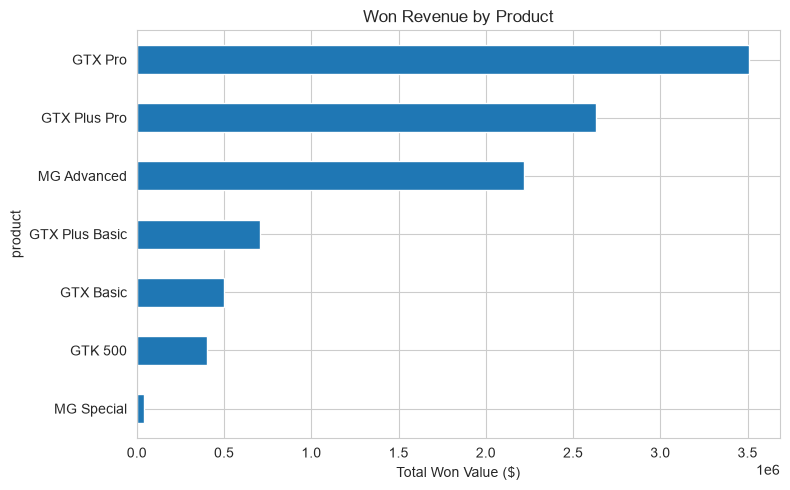

In [30]:
plt.figure(figsize=(8, 5))
product_summary.sort_values('total_won_value', ascending=True)['total_won_value'].plot(kind='barh')
plt.xlabel('Total Won Value ($)')
plt.title('Won Revenue by Product')
plt.tight_layout()
plt.show()


**Win rates cluster ~60–65% across all products — revenue concentration is driven by volume × deal size, not by win rate.** GTX Pro, GTX Plus Pro, and MG Advanced together generate **83.5%** of Won revenue. Notably, GTX Basic has the *most wins* (915) but only ~$499K in Won value, while MG Special wins 793 times for barely $44K — high win *count* is not the same as high revenue. GTK 500 has only 15 wins; its high median deal value shouldn't be read as a strong signal given the small sample.

**Limitation:** revenue is not profit. No cost data exists, so these products can be called highest-*revenue*, not highest-*value* to the business.

## 9. Sales-cycle analysis

This is the project's strongest analytical thread — a finding is proposed, then deliberately stress-tested.

In [31]:
closed.groupby('deal_stage')['sales_cycle_days'].agg(['count', 'mean', 'median', 'min', 'max'])


,count,mean,median,min,max
deal_stage,,,,,
Lost,2473,41.48,14.00,1,138
Won,4238,51.78,57.00,1,138


Won deals take meaningfully longer to close than Lost deals (median 57 vs. 14 days).

In [32]:
bins = [0, 7, 14, 30, 60, 90, 138]
labels = ['1-7', '8-14', '15-30', '31-60', '61-90', '91-138']
closed['cycle_bucket'] = pd.cut(closed['sales_cycle_days'], bins=bins, labels=labels)

cycle_analysis = closed.groupby('cycle_bucket', observed=True).agg(
    opportunities=('opportunity_id', 'count'),
    win_rate=('deal_stage', lambda x: (x == 'Won').mean() * 100)
)
cycle_analysis


,opportunities,win_rate
cycle_bucket,,
1-7,1413,53.50
8-14,1393,57.50
15-30,357,72.83
31-60,569,66.26
61-90,1621,66.50
91-138,1358,71.13


### 9.1 Threshold search

Test a range of day cutoffs to find where the win-rate gap is largest.

In [33]:
thresholds = [7, 14, 21, 30, 45, 60, 90]
rows = []
for t in thresholds:
    short = closed['sales_cycle_days'] <= t
    long = closed['sales_cycle_days'] > t
    short_rate = closed.loc[short, 'deal_stage'].eq('Won').mean() * 100
    long_rate = closed.loc[long, 'deal_stage'].eq('Won').mean() * 100
    rows.append({
        'threshold_days': t,
        'opportunities_<=_threshold': short.sum(),
        'win_rate_<=_threshold': short_rate,
        'opportunities_>_threshold': long.sum(),
        'win_rate_>_threshold': long_rate,
        'difference_pp': long_rate - short_rate
    })

threshold_df = pd.DataFrame(rows)
threshold_df


,threshold_days,opportunities_<=_threshold,win_rate_<=_threshold,opportunities_>_threshold,win_rate_>_threshold,difference_pp
0,7,1413,53.50,5298,65.72,12.22
1,14,2806,55.49,3905,68.66,13.17
2,21,3109,57.03,3602,68.43,11.41
3,30,3163,57.45,3548,68.24,10.79
4,45,3358,57.89,3353,68.42,10.52
5,60,3732,58.79,2979,68.61,9.82
6,90,5353,61.12,1358,71.13,10.01


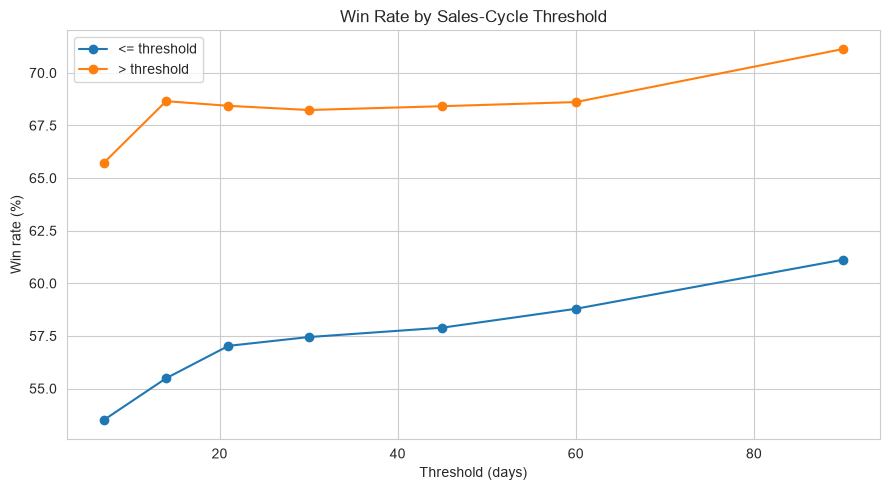

In [34]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_df['threshold_days'], threshold_df['win_rate_<=_threshold'], marker='o', label='<= threshold')
plt.plot(threshold_df['threshold_days'], threshold_df['win_rate_>_threshold'], marker='o', label='> threshold')
plt.xlabel('Threshold (days)')
plt.ylabel('Win rate (%)')
plt.title('Win Rate by Sales-Cycle Threshold')
plt.legend()
plt.tight_layout()
plt.show()


**Finding:** the 14-day split produces the largest gap — **55.5%** win rate at or under 14 days vs. **68.7%** above it (**13.2 percentage points**). The `>` line sits above the `<=` line at every threshold tested.

**Interpretation (deliberately non-causal):** *"Longer sales cycles were associated with higher observed win rates"* — not *"longer cycles cause wins."* A plausible mechanism: weak-fit opportunities get rejected quickly (showing up as fast Lost deals), while genuinely promising opportunities take longer due to negotiation and multiple stakeholders — and are also more likely to eventually win. Cycle length may be a *symptom* of deal quality that was already present, not a cause of winning.

### 9.2 Validate across product and sector

Does the pattern hold everywhere, or is it driven by one segment?

In [35]:
cycle_by_product = (
    closed.groupby(['product', 'cycle_bucket'], observed=True)
    .agg(opportunities=('opportunity_id', 'count'),
         win_rate=('deal_stage', lambda x: (x == 'Won').mean() * 100))
    .reset_index()
)
cycle_by_product


,product,cycle_bucket,opportunities,win_rate
0,GTK 500,1-7,4,50.00
1,GTK 500,8-14,3,33.33
2,GTK 500,15-30,3,66.67
3,GTK 500,31-60,3,33.33
4,GTK 500,61-90,5,60.00
5,GTK 500,91-138,7,85.71
6,GTX Basic,1-7,293,52.22
7,GTX Basic,8-14,269,54.28
8,GTX Basic,15-30,80,78.75
9,GTX Basic,31-60,133,68.42


In [36]:
cycle_by_sector = (
    closed.groupby(['sector', 'cycle_bucket'], observed=True)
    .agg(opportunities=('opportunity_id', 'count'),
         win_rate=('deal_stage', lambda x: (x == 'Won').mean() * 100))
    .reset_index()
)
cycle_by_sector


,sector,cycle_bucket,opportunities,win_rate
0,employment,1-7,54,50.00
1,employment,8-14,60,55.00
2,employment,15-30,15,66.67
3,employment,31-60,27,74.07
4,employment,61-90,73,67.12
5,employment,91-138,57,70.18
6,entertainment,1-7,78,65.38
7,entertainment,8-14,84,58.33
8,entertainment,15-30,24,79.17
9,entertainment,31-60,37,64.86


The short-cycle/lower-win-rate pattern holds across products and sectors — it isn't one segment driving the overall number.

**Limitation:** this cannot be used to predict outcomes for *currently open* deals under 14 days — a deal that eventually takes 90 days to win also spent time at day 5, day 10, and day 13 first. The finding describes *completed* cycles only.

## 10. Sales-agent analysis

In [37]:
agent_summary = (
    closed.groupby('sales_agent')
    .agg(closed=('opportunity_id', 'count'),
         won=('deal_stage', lambda x: (x == 'Won').sum()),
         total_won_value=('close_value', 'sum'),
         median_deal_value=('close_value', 'median'))
)
agent_summary['win_rate'] = (agent_summary['won'] / agent_summary['closed'] * 100).round(1)
agent_summary.sort_values('win_rate', ascending=False).head(10)


,closed,won,total_won_value,median_deal_value,win_rate
sales_agent,,,,,
Hayden Neloms,152,107,"272,111.00","1,157.00",70.40
Maureen Marcano,213,149,"350,395.00",891.00,70.00
Wilburn Farren,79,55,"157,640.00",592.00,69.60
Cecily Lampkin,160,107,"229,800.00",470.00,66.90
Versie Hillebrand,264,176,"187,693.00",54.00,66.70
Moses Frase,195,129,"207,182.00",465.00,66.20
Boris Faz,153,101,"261,631.00",574.00,66.00
Corliss Cosme,229,150,"421,036.00",586.00,65.50
James Ascencio,206,135,"413,533.00",539.00,65.50


### 10.1 Validate: does the ranking hold within a single product?

Overall agent ranking could simply reflect *which products each agent happened to sell*, not skill. Holding one high-volume product fixed (GTX Basic) tests this directly.

In [38]:
gtx_basic_agents = (
    closed[closed['product'] == 'GTX Basic']
    .groupby('sales_agent')
    .agg(closed=('opportunity_id', 'count'),
         won=('deal_stage', lambda x: (x == 'Won').sum()))
)
gtx_basic_agents['win_rate'] = (gtx_basic_agents['won'] / gtx_basic_agents['closed'] * 100).round(1)
gtx_basic_agents.sort_values('win_rate', ascending=False)


,closed,won,win_rate
sales_agent,,,
Elease Gluck,16,13,81.20
Moses Frase,59,47,79.70
Rosie Papadopoulos,9,7,77.80
Wilburn Farren,12,9,75.00
Darcel Schlecht,53,36,67.90
Vicki Laflamme,83,56,67.50
Corliss Cosme,54,36,66.70
Cecily Lampkin,24,16,66.70
Rosalina Dieter,15,10,66.70


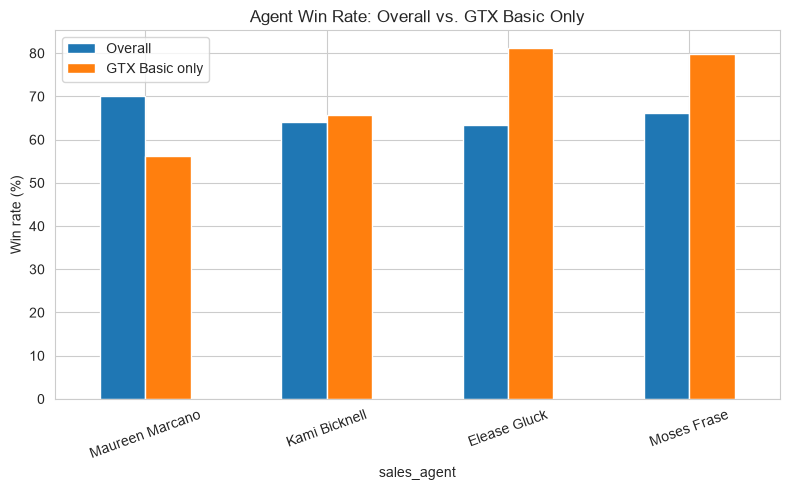

In [39]:
compare_agents = ['Maureen Marcano', 'Kami Bicknell', 'Elease Gluck', 'Moses Frase']

comparison = pd.DataFrame({
    'Overall': agent_summary.loc[compare_agents, 'win_rate'],
    'GTX Basic only': gtx_basic_agents.loc[compare_agents, 'win_rate']
})

comparison.plot(kind='bar', figsize=(8, 5))
plt.ylabel('Win rate (%)')
plt.title('Agent Win Rate: Overall vs. GTX Basic Only')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Finding:** the ranking scrambles. Agents who rank near the top overall (e.g., Maureen Marcano) can fall near the bottom on a single product, while agents who don't appear in the overall top list (e.g., Elease Gluck, Moses Frase) top the GTX-Basic-only ranking.

**Limitation:** small-sample agents (e.g., 16 closed deals) cannot be trusted at the top of a ranking either — compare Elease Gluck (81% on 16 deals) against Kami Bicknell (66% on 108 deals) before drawing conclusions.

**Conclusion:** overall agent performance is confounded by product mix. A fair agent comparison requires controlling for product (and sample size) — a raw leaderboard is not defensible.

## 11. Open pipeline & pipeline age

Dataset ends 2017-12-31 — that's the correct snapshot date for age calculations, not today's date.

In [40]:
open_pipeline = df_pipeline[df_pipeline['deal_stage'].isin(['Prospecting', 'Engaging'])].copy()
print('Open opportunities:', len(open_pipeline))
print(open_pipeline['deal_stage'].value_counts())


Open opportunities: 2089
deal_stage
Engaging       1589
Prospecting     500
Name: count, dtype: int64


In [41]:
SNAPSHOT_DATE = pd.Timestamp('2017-12-31')
open_pipeline['age_days'] = (SNAPSHOT_DATE - open_pipeline['engage_date']).dt.days

open_pipeline.groupby('deal_stage')['age_days'].agg(['count', 'mean', 'median', 'min', 'max'])


,count,mean,median,min,max
deal_stage,,,,,
Engaging,1589,198.82,165.00,9.00,423.00
Prospecting,0,NaN,NaN,NaN,NaN


`Prospecting` returns all-NaN — confirmed structural, not a bug (see Section 3). Age can only be reported for `Engaging` deals (median 165 days).

### 11.1 Flag stalled opportunities

Threshold: the **longest cycle among Won deals** — not the combined Won+Lost max. An open deal is trying to become a Won deal, so that's the right historical comparison point.

In [42]:
won_max_cycle = closed.loc[closed['deal_stage'] == 'Won', 'sales_cycle_days'].max()

open_pipeline['stalled'] = np.where(
    open_pipeline['age_days'].isna(), 'Unknown (no engage_date)',
    np.where(open_pipeline['age_days'] > won_max_cycle, 'Stalled', 'Normal')
)

open_pipeline.groupby(['deal_stage', 'stalled'])['opportunity_id'].count()


deal_stage   stalled                 
Engaging     Normal                       298
             Stalled                     1291
Prospecting  Unknown (no engage_date)     500
Name: opportunity_id, dtype: int64

**81% of Engaging deals (1,291 of 1,589)** have already run longer than any deal the company has ever won. The 500 Prospecting deals are labeled `Unknown` rather than defaulted to `Normal` — `NaN > threshold` silently evaluates to `False` in pandas, which would otherwise mislabel unmeasurable deals as healthy.

### 11.2 Estimated exposure by product

Open deals have no `close_value` (they haven't closed). `products.sales_price` (list price) is used as a stand-in — **this is an estimate of potential value if a deal closed as Won, not a revenue forecast**; actual negotiated values vary per deal.

In [43]:
open_pipeline = open_pipeline.merge(products[['product', 'sales_price']], on='product', how='left')

exposure = (
    open_pipeline.groupby(['stalled', 'product'])
    .agg(count=('opportunity_id', 'count'), est_value=('sales_price', 'sum'))
    .sort_values('est_value', ascending=False)
)
exposure


count  est_value
stalled                  product                         
Stalled                  GTX Pro           197     949737
                         GTX Plus Pro      139     761998
                         MG Advanced       213     722709
Unknown (no engage_date) GTX Pro            80     385680
Stalled                  GTK 500            14     374752
Unknown (no engage_date) MG Advanced        86     291798
Normal                   GTX Pro            56     269976
Unknown (no engage_date) GTX Plus Pro       47     257654
Stalled                  GTX Plus Basic    203     222488
Normal                   GTX Plus Pro       37     202834
Stalled                  GTX Basic         279     153450
Normal                   MG Advanced        29      98397
Unknown (no engage_date) GTX Plus Basic     74      81104
Normal                   GTX Plus Basic     55      60280
Unknown (no engage_date) GTX Basic          93      51150
Normal                   GTX Basic          58      31900
                         GTK 500             1      26768
Stalled                  MG Special        246      13530
Unknown (no engage_date) MG Special        120       6600
Normal                   MG Special         62       3410

In [44]:
stalled_only = exposure.loc['Stalled'].sort_values('est_value', ascending=False)
stalled_only['pct_of_stalled'] = stalled_only['est_value'] / stalled_only['est_value'].sum() * 100
stalled_only


,count,est_value,pct_of_stalled
product,,,
GTX Pro,197,949737,29.69
GTX Plus Pro,139,761998,23.82
MG Advanced,213,722709,22.59
GTK 500,14,374752,11.72
GTX Plus Basic,203,222488,6.96
GTX Basic,279,153450,4.80
MG Special,246,13530,0.42


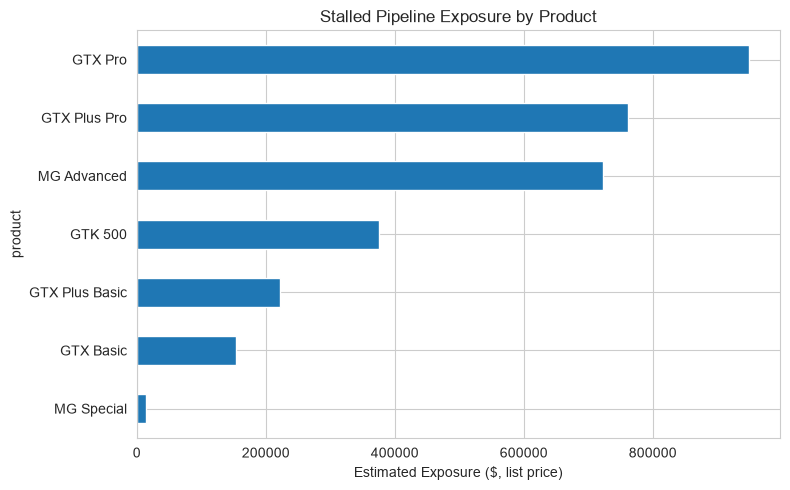

In [45]:
plt.figure(figsize=(8, 5))
stalled_only['est_value'].plot(kind='barh')
plt.xlabel('Estimated Exposure ($, list price)')
plt.title('Stalled Pipeline Exposure by Product')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**$949,737 of stalled pipeline exposure sits in GTX Pro alone — 29.7% of all stalled exposure.** These deals have already run longer than any deal ever won; that doesn't prove they can't still close, but there is no historical precedent for a win at this length, which makes them worth flagging for review.

### 11.3 Validate: is stalled rate reliable, or a small-sample artifact?

In [46]:
product_stalled = (
    open_pipeline.groupby('product')
    .agg(open_opportunities=('opportunity_id', 'count'),
         stalled_opportunities=('stalled', lambda x: (x == 'Stalled').sum()),
         stalled_exposure=('sales_price', lambda s: s[open_pipeline.loc[s.index, 'stalled'] == 'Stalled'].sum()))
)
product_stalled['stalled_rate'] = (product_stalled['stalled_opportunities'] / product_stalled['open_opportunities'] * 100).round(1)
product_stalled.sort_values('stalled_rate', ascending=False)


,open_opportunities,stalled_opportunities,stalled_exposure,stalled_rate
product,,,,
GTK 500,15,14,374752,93.30
GTX Basic,430,279,153450,64.90
MG Advanced,328,213,722709,64.90
GTX Plus Pro,223,139,761998,62.30
GTX Plus Basic,332,203,222488,61.10
GTX Pro,333,197,949737,59.20
MG Special,428,246,13530,57.50


GTK 500 shows the highest stalled rate (93%) but on only 15 open opportunities — not trustworthy. **GTX Pro and MG Advanced are the real concern**: high stalled rates (59–65%) on a large, reliable base (300+ open opportunities each).

## 12. Revisit: does sector actually matter?

Section 6 found sector win rates clustered tightly — but every sector sells roughly the same product mix, which can *mask* a real sector effect at the overall level. Holding product fixed tests this.

In [47]:
gtx_pro_by_sector = sector_product.loc[(slice(None), 'GTX Pro'), :].droplevel('product')
gtx_pro_by_sector.sort_values('win_rate')


,closed,won,win_rate
sector,,,
employment,55,30,54.50
telecommunications,73,42,57.50
medical,149,89,59.70
entertainment,62,37,59.70
retail,216,137,63.40
software,137,87,63.50
finance,109,71,65.10
technolgy,183,121,66.10
marketing,99,69,69.70


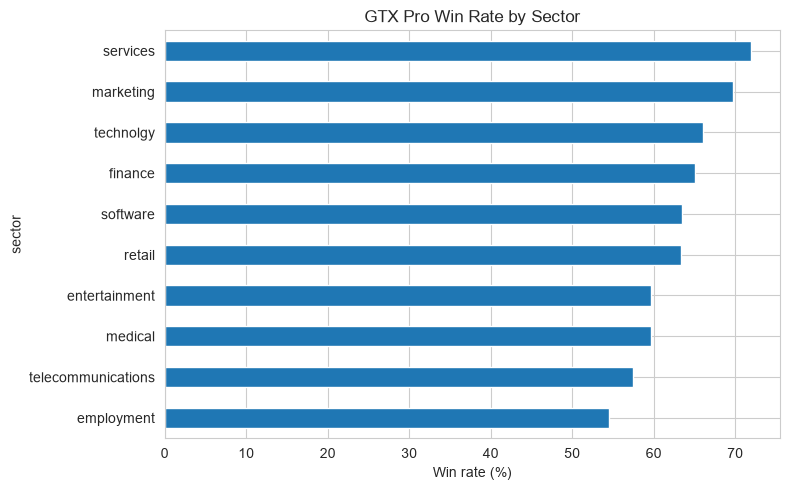

In [48]:
plt.figure(figsize=(8, 5))
gtx_pro_by_sector.sort_values('win_rate')['win_rate'].plot(kind='barh')
plt.xlabel('Win rate (%)')
plt.title('GTX Pro Win Rate by Sector')
plt.tight_layout()
plt.show()


**Within GTX Pro alone, win rate swings from 54.5% (employment) to 71.9% (services) — a 17.4 percentage-point range**, wider than the sales-cycle finding this project spent three sections validating. Sector *does* matter; the overall clustering in Section 6 was a product-mix illusion, the same trap as the agent ranking in Section 10.

**Limitation:** some sector×product cells are small (e.g., employment×GTX Pro at 55 closed deals) — not every gap in this table carries equal weight.

## 13. Key findings — cross-validated

Every finding below was checked for an alternative explanation before being accepted.

| # | Finding | Evidence | Alternative explanation | Validation | Limitation |
|---|---|---|---|---|---|
| 1 | Short sales cycles (≤14 days) have a lower win rate | 55.5% vs. 68.7% (13.2pp gap), tested across 7 thresholds | Cycle length reflects pre-existing deal quality, not a cause of winning | Holds across products and sectors | Can't predict outcomes for currently-open short-cycle deals (survivorship) |
| 2 | GTX Pro + GTX Plus Pro + MG Advanced = 83.5% of Won revenue | Revenue decomposed into volume × deal size; win rates cluster 60–65% | High revenue could reflect volume, price, or both | Confirmed via decomposition | Revenue ≠ profit — no cost data |
| 3 | Agent performance rankings are confounded by product mix | GTX-Basic-only ranking vs. overall ranking | Overall ranking reflects skill | Ranking scrambles when product is held fixed | Small-sample agents (<20 deals) unreliable at either end |
| 4 | 81% of Engaging deals are stalled past the longest-ever winning cycle | Age vs. `won_max_cycle` threshold, $949,737 exposure in GTX Pro | High stalled rate could be a small-sample artifact | GTX Pro/MG Advanced hold on 300+ opportunity bases (GTK 500's 93% does not) | Exposure is list-price-based, not a revenue forecast |
| 5 | Sector has little effect on win rate | Sector-level win rates cluster 55–65% | Product mix masks a real sector effect | GTX Pro alone swings 54.5%→71.9% by sector | Some sector×product cells are small |


## 14. Business recommendations

Each recommendation follows: Finding → Evidence → Interpretation → Action → Limitation. No invented impact numbers — every action is traceable to a validated finding above.

| # | Finding | Action | Limitation |
|---|---|---|---|
| 1 | Short cycles (≤14 days) have a lower win rate (55.5% vs. 68.7%) | Prioritize follow-up calls on deals past day 14; use them to identify what's driving continued buyer interest, informing future deal qualification | Cannot predict outcomes for currently-open short-cycle deals — some eventual wins also looked short-cycle early on |
| 2 | GTX Pro, GTX Plus Pro, MG Advanced generate 83.5% of Won revenue despite similar win rates across products | When agents must choose where to spend limited time among similarly-likely deals, prioritize these three products — same conversion odds, far higher payoff per win | Revenue ≠ profit; no cost data, so this is "highest-revenue," not "most profitable" |
| 3 | Agent rankings scramble once product is held fixed — overall ranking reflects product mix, not just skill | Before reassigning agents by "best product," recompute per-agent, per-product win rates on adequate sample sizes (30+ deals) across more products; track future performance with product-mix noted, not raw revenue alone | Small-sample agent-product cells (<20 deals) can't be trusted at either end of a ranking |
| 4 | 81% of Engaging deals (1,291) exceed the longest-ever winning cycle; $949,737 exposure concentrated in GTX Pro | Trigger a proactive check-in call for any deal past the historical max winning cycle — the call, not the day count, decides whether to re-engage or close; prioritize GTX Pro deals given concentrated exposure | Exposure is list-price-based, not a revenue forecast; passing the threshold doesn't prove the deal can't still close |
| 5 | Sector appears to have little effect overall, but within GTX Pro alone win rate swings 54.5%→71.9% by sector | Confirm sample sizes are adequate per sector×product cell; if the gap holds, prioritize GTX Pro sales effort toward higher-performing sectors (e.g. services) and investigate what differs operationally | Some sector×product cells are small (as low as 55 deals) — not every gap carries equal weight |